In [ ]:
import pandas as pd

In [2]:
jkt_temp = pd.read_csv("data/jakarta-temperature.csv", skiprows=3)
mks_temp = pd.read_csv("data/makassar-temperature.csv", skiprows=3)
sby_temp = pd.read_csv("data/surabaya-temperature.csv", skiprows=3)

In [12]:
jkt_temp['Date'] = pd.to_datetime(jkt_temp['time'])
mks_temp['Date'] = pd.to_datetime(mks_temp['time'])
sby_temp['Date'] = pd.to_datetime(sby_temp['time'])

jkt_temp.set_index("Date", inplace=True)
mks_temp.set_index("Date", inplace=True)
sby_temp.set_index("Date", inplace=True)

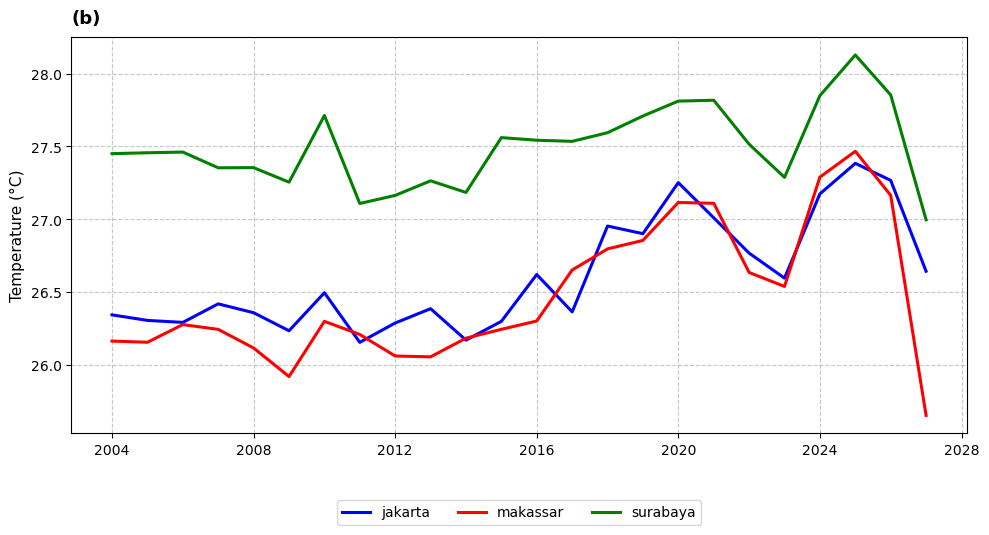

In [27]:
import matplotlib.pyplot as plt


jkt_monthly = jkt_temp.resample("YE").mean(numeric_only=True)
mks_monthly = mks_temp.resample("YE").mean(numeric_only=True)
sby_monthly = sby_temp.resample("YE").mean(numeric_only=True)

plt.figure(figsize=(10, 5.5), dpi=100)

plt.plot(jkt_monthly.index, jkt_monthly['temperature_2m (°C)'],   color='blue',   linewidth=2.2, label='jakarta')
plt.plot(mks_monthly.index, mks_monthly['temperature_2m (°C)'],   color='red',    linewidth=2.2, label='makassar')
plt.plot(sby_monthly.index, sby_monthly['temperature_2m (°C)'],  color='green',  linewidth=2.2, label='surabaya')

plt.title('(b)', fontsize=13, fontweight='bold', loc='left', pad=10)
plt.ylabel('Temperature (°C)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

# Date formatting
# plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%Y'))
plt.xticks(rotation=0, ha='center')

# plt.ylim(24, 36)
# Legend
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=10)

plt.tight_layout()
plt.show()

DatetimeIndexResampler [freq=<MonthEnd>, closed=right, label=right, convention=start, origin=start_day]


In [ ]:
import numpy as np
import pandas as pd
import requests
import time
from math import radians, cos, sin, asin, sqrt
import random

lat_min = -8.9
lat_max = -5.8
lon_min = 105.0
lon_max = 114.5

grid_resolution = 0.5
min_distance_deg = 0.7
target_sample_size = 50

random_seed = 42
random.seed(random_seed)

# =========================
# HELPER FUNCTIONS
# =========================

def haversine(lat1, lon1, lat2, lon2):
    """
    Compute distance between two lat/lon points in km.
    """
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    return R * c

def is_far_enough(candidate, selected, min_deg):
    for lat2, lon2, _ in selected:
        if abs(candidate[0] - lat2) < min_deg and abs(candidate[1] - lon2) < min_deg:
            return False
    return True

def get_elevation(lat, lon):
    url = f"https://api.open-meteo.com/v1/elevation?latitude={lat}&longitude={lon}"
    try:
        response = requests.get(url, timeout=10)
        data = response.json()
        return data["elevation"][0]
    except:
        return None

# =========================
# STEP 1 — CREATE GRID
# =========================

lat_points = np.arange(lat_min, lat_max, grid_resolution)
lon_points = np.arange(lon_min, lon_max, grid_resolution)

grid = [(lat, lon) for lat in lbt_points for lon in lon_points]

print(f"Initial grid points: {len(grid)}")

# =========================
# STEP 2 — QUERY ELEVATION
# =========================

points_with_elevation = []

for lat, lon in grid:
    elevation = get_elevation(lat, lon)
    time.sleep(0.2)  # avoid API overload
    
    if elevation is None:
        continue
    
    if elevation == 0:
        continue  # remove ocean
    
    points_with_elevation.append((lat, lon, elevation))

print(f"Land points after filtering ocean: {len(points_with_elevation)}")

# =========================
# STEP 3 — ELEVATION STRATIFICATION
# =========================

coastal = []
mid = []
highland = []

for lat, lon, elev in points_with_elevation:
    if elev < 50:
        coastal.append((lat, lon, elev))
    elif elev < 500:
        mid.append((lat, lon, elev))
    else:
        highland.append((lat, lon, elev))

print("Elevation bins:")
print("Coastal:", len(coastal))
print("Mid:", len(mid))
print("Highland:", len(highland))

# =========================
# STEP 4 — BALANCED SAMPLING
# =========================

selected_points = []

def sample_from_bin(bin_points, n_needed):
    sampled = []
    random.shuffle(bin_points)
    for candidate in bin_points:
        if len(sampled) >= n_needed:
            break
        if is_far_enough(candidate, selected_points + sampled, min_distance_deg):
            sampled.append(candidate)
    return sampled

n_coastal = int(target_sample_size * 0.3)
n_mid = int(target_sample_size * 0.4)
n_high = target_sample_size - n_coastal - n_mid

selected_points += sample_from_bin(coastal, n_coastal)
selected_points += sample_from_bin(mid, n_mid)
selected_points += sample_from_bin(highland, n_high)

print(f"Selected points: {len(selected_points)}")

# =========================
# STEP 5 — SAVE RESULTS
# =========================

df = pd.DataFrame(selected_points, columns=["latitude", "longitude", "elevation"])
df.to_csv("selected_stations.csv", index=False)

print("Saved selected stations to selected_stations.csv")
print(df)

Initial grid points: 133
Land points after filtering ocean: 42
Elevation bins:
Coastal: 13
Mid: 19
Highland: 10
Selected points: 14
Saved selected stations to selected_stations.csv
    latitude  longitude  elevation
0       -6.9      111.0       17.0
1       -7.4      108.5       26.0
2       -6.9      113.0       18.0
3       -6.4      108.0       10.0
4       -6.9      109.5        9.0
5       -6.9      112.0       13.0
6       -8.4      112.5       32.0
7       -7.4      107.0       20.0
8       -6.4      106.0      121.0
9       -7.9      111.5      108.0
10      -6.4      107.0       72.0
11      -6.9      114.0       73.0
12      -7.9      114.0      354.0
13      -7.9      110.5      146.0


In [11]:
import numpy as np
import pandas as pd
import requests
import time
from math import radians, cos, sin, asin, sqrt
import random

lat_min = -10.5
lat_max = 1.5
lon_min = 130.5
lon_max = 141.0

grid_resolution = 0.25
min_distance_deg = 0.7
target_sample_size = 50

random_seed = 42
random.seed(random_seed)

# =========================
# HELPER FUNCTIONS
# =========================

def haversine(lat1, lon1, lat2, lon2):
    """
    Compute distance between two lat/lon points in km.
    """
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    return R * c

def is_far_enough(candidate, selected, min_deg):
    for lat2, lon2, _ in selected:
        if abs(candidate[0] - lat2) < min_deg and abs(candidate[1] - lon2) < min_deg:
            return False
    return True

def get_elevation(lat, lon):
    url = f"https://api.open-meteo.com/v1/elevation?latitude={lat}&longitude={lon}"
    try:
        response = requests.get(url, timeout=10)
        data = response.json()
        return data["elevation"][0]
    except:
        return None

# =========================
# STEP 1 — CREATE GRID
# =========================

lat_points = np.arange(lat_min, lat_max, grid_resolution)
lon_points = np.arange(lon_min, lon_max, grid_resolution)

grid = [(lat, lon) for lat in lat_points for lon in lon_points]

print(f"Initial grid points: {len(grid)}")

# =========================
# STEP 2 — QUERY ELEVATION
# =========================

points_with_elevation = []

for lat, lon in grid:
    elevation = get_elevation(lat, lon)
    time.sleep(0.2)  # avoid API overload
    
    if elevation is None:
        continue
    
    if elevation == 0:
        continue  # remove ocean
    
    points_with_elevation.append((lat, lon, elevation))

print(f"Land points after filtering ocean: {len(points_with_elevation)}")

# =========================
# STEP 3 — ELEVATION STRATIFICATION
# =========================

coastal = []
mid = []
highland = []

for lat, lon, elev in points_with_elevation:
    if elev < 50:
        coastal.append((lat, lon, elev))
    elif elev < 500:
        mid.append((lat, lon, elev))
    else:
        highland.append((lat, lon, elev))

print("Elevation bins:")
print("Coastal:", len(coastal))
print("Mid:", len(mid))
print("Highland:", len(highland))

# =========================
# STEP 4 — BALANCED SAMPLING
# =========================

selected_points = []

def sample_from_bin(bin_points, n_needed):
    sampled = []
    random.shuffle(bin_points)
    for candidate in bin_points:
        if len(sampled) >= n_needed:
            break
        if is_far_enough(candidate, selected_points + sampled, min_distance_deg):
            sampled.append(candidate)
    return sampled

n_coastal = int(target_sample_size * 0.3)
n_mid = int(target_sample_size * 0.4)
n_high = target_sample_size - n_coastal - n_mid

selected_points += sample_from_bin(coastal, n_coastal)
selected_points += sample_from_bin(mid, n_mid)
selected_points += sample_from_bin(highland, n_high)

print(f"Selected points: {len(selected_points)}")

# =========================
# STEP 5 — SAVE RESULTS
# =========================

df = pd.DataFrame(selected_points, columns=["latitude", "longitude", "elevation"])
df.to_csv("papua_selected_stations_grid.csv", index=False)

print("Saved selected stations to selected_stations.csv")
print(df)

Initial grid points: 2016
Land points after filtering ocean: 524
Elevation bins:
Coastal: 206
Mid: 186
Highland: 132
Selected points: 47
Saved selected stations to selected_stations.csv
    latitude  longitude  elevation
0      -7.50     140.75       41.0
1      -7.75     138.00        7.0
2      -1.00     137.75       21.0
3      -5.00     139.25       22.0
4      -6.75     139.50       26.0
5      -6.75     140.50       32.0
6      -7.50     139.25        9.0
7      -4.75     136.75       18.0
8      -6.00     140.50       35.0
9      -1.00     132.25       22.0
10     -7.25     131.50       27.0
11     -2.00     134.50       10.0
12     -5.25     137.75       28.0
13     -8.50     140.75       18.0
14     -2.75     133.75       46.0
15     -2.25     139.25       89.0
16     -3.25     140.75      429.0
17     -2.75     138.00       84.0
18     -4.00     139.75       90.0
19     -1.75     136.75       70.0
20     -0.75     135.75       95.0
21     -1.50     133.25      397.0
22     -3

In [ ]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://api.open-meteo.com/v1/forecast"
params = {
	"latitude": [-8.7, -8.4, -8.3, -8.4, -8.5, -9.5, -9.7, -10, -9.5, -8.6, -9.4, -8.5],
	"longitude": [122.5, 122.6, 120.3, 120.8, 119.9, 119.6, 120.4, 120.4, 119, 121.6, 119.9, 118.7],
	"hourly": "temperature_2m",
}
responses = openmeteo.weather_api(url, params=params)



# Process 12 locations
for response in responses:
	latitude = response.Latitude()
	longtitude = response.Longitude()
	print(f"\nCoordinates: {latitude}°N {longtitude}°E")
	print(f"Elevation: {response.Elevation()} m asl")
	print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")
	
	# Process hourly data. The order of variables needs to be the same as requested.
	hourly = response.Hourly()
	hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
	
	hourly_data = {"date": pd.date_range(
		start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = hourly.Interval()),
		inclusive = "left"),
		"latitude" : latitude,
		"longtitude" : longtitude
	}
	
	hourly_data["temperature_2m"] = hourly_temperature_2m
	
	hourly_dataframe = pd.DataFrame(data = hourly_data)
	print("\nHourly data\n", hourly_dataframe)
	


Coordinates: -8.625°N 122.5°E
Elevation: 434.0 m asl
Timezone difference to GMT+0: 0s

Hourly data
                          date  latitude  longtitude  temperature_2m
0   2026-02-21 00:00:00+00:00    -8.625       122.5       24.552999
1   2026-02-21 01:00:00+00:00    -8.625       122.5       25.253000
2   2026-02-21 02:00:00+00:00    -8.625       122.5       25.703001
3   2026-02-21 03:00:00+00:00    -8.625       122.5       26.052999
4   2026-02-21 04:00:00+00:00    -8.625       122.5       26.603001
..                        ...       ...         ...             ...
163 2026-02-27 19:00:00+00:00    -8.625       122.5       23.103001
164 2026-02-27 20:00:00+00:00    -8.625       122.5       23.003000
165 2026-02-27 21:00:00+00:00    -8.625       122.5       23.103001
166 2026-02-27 22:00:00+00:00    -8.625       122.5       23.552999
167 2026-02-27 23:00:00+00:00    -8.625       122.5       24.153000

[168 rows x 4 columns]

Coordinates: -8.5°N 122.5°E
Elevation: 9.0 m asl
Timezone 

### Merged Temp & Station Dataframe

In [ ]:
max_temp_df = pd.read_csv("data/sumatra/sumatra-max-temp.csv")
station_df = pd.read_csv("data/sumatra/sumatra-station.csv")

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [ ]:
merged_df = max_temp_df.merge( # join the datasets
    station_df[['location_id', 'latitude', 'longitude', 'elevation']],
    on="location_id", # matching keys
    how='left' # keep all temperature rows
)
merged_df.to_csv("data/sumatra/sumatra-merged.csv", index=False)

### Convert Station Names

In [4]:
def convert_station_code(df, prefix):
    df['location_id'] = prefix + (df['location_id'] + 1).astype(str).str.zfill(2)
    return df

In [1]:
print("test")

test


In [5]:
import pandas as pd
java_df = pd.read_csv("data/java/java-merged.csv")
maluku_df = pd.read_csv("data/maluku/maluku-merged.csv")
ntt_df = pd.read_csv("data/ntt/ntt-merged.csv")
papua_df = pd.read_csv("data/ntt/ntt-merged.csv")
sumatra_df = pd.read_csv("data/ntt/ntt-merged.csv")

java_df = convert_station_code(java_df, "J")
maluku_df = convert_station_code(maluku_df, "M")
ntt_df = convert_station_code(ntt_df, "N")
papua_df = convert_station_code(papua_df, "P")
sumatra_df = convert_station_code(sumatra_df, "S")

### Get Temporal Feature

In [6]:
import numpy as np
def get_solar_declination(df):
    df['time'] = pd.to_datetime(df['time'])
    df['year'] = df['time'].dt.year
    df['doy'] = df['time'].dt.dayofyear
    df["sin_doy"] = np.sin(2 * np.pi * df["doy"] / 365) # tells us where we are in the yearly seasonal cycle
    df["cos_doy"] = np.cos(2 * np.pi * df["doy"] / 365)

    df["solar_declination"] = 23.44 * np.sin( # how strong is the position today 
        2 * np.pi * (284 + df["doy"]) / 365
    )
    return df


In [7]:
java_df = get_solar_declination(java_df)
maluku_df = get_solar_declination(maluku_df)
ntt_df = get_solar_declination(ntt_df)
papua_df = get_solar_declination(papua_df)
sumatra_df = get_solar_declination(sumatra_df)

### ENSO & Dipole Index

In [8]:
java_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 161091 entries, 0 to 161090
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   location_id              161091 non-null  str           
 1   time                     161091 non-null  datetime64[us]
 2   temperature_2m_max (°C)  161091 non-null  float64       
 3   latitude                 161091 non-null  float64       
 4   longitude                161091 non-null  float64       
 5   elevation                161091 non-null  float64       
 6   year                     161091 non-null  int32         
 7   doy                      161091 non-null  int32         
 8   sin_doy                  161091 non-null  float64       
 9   cos_doy                  161091 non-null  float64       
 10  solar_declination        161091 non-null  float64       
dtypes: datetime64[us](1), float64(7), int32(2), str(1)
memory usage: 12.3 MB


In [9]:
dmi_df = pd.read_csv("data/dmieast.had.long.csv")
enso_df = pd.read_csv("data/nina34.anom.csv")
# def get_enso_dmi(df, dmi_df, enso_df):
enso_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           264 non-null    str    
 1   Nino Anom 3.4  264 non-null    float64
dtypes: float64(1), str(1)
memory usage: 4.3 KB


In [32]:
dmi_df['Date'] = pd.to_datetime(dmi_df['Date'], dayfirst=True)
dmi_df['Date'].dt.month

0       1
1       2
2       3
3       4
4       5
       ..
247     8
248     9
249    10
250    11
251    12
Name: Date, Length: 252, dtype: int32

In [15]:
java_df

,location_id,time,temperature_2m_max (°C),latitude,longitude,elevation,year,doy,sin_doy,cos_doy,solar_declination
0,J01,2005-01-01,30.5,-6.854130,111.00253,17.0,2005,1,1.721336e-02,0.999852,-23.001824
1,J01,2005-01-02,30.5,-6.854130,111.00253,17.0,2005,2,3.442161e-02,0.999407,-22.920765
2,J01,2005-01-03,30.9,-6.854130,111.00253,17.0,2005,3,5.161967e-02,0.998667,-22.832915
3,J01,2005-01-04,30.8,-6.854130,111.00253,17.0,2005,4,6.880243e-02,0.997630,-22.738298
4,J01,2005-01-05,29.5,-6.854130,111.00253,17.0,2005,5,8.596480e-02,0.996298,-22.636944
...,...,...,...,...,...,...,...,...,...,...,...
161086,J21,2025-12-28,30.0,-7.486819,109.63498,345.0,2025,362,-5.161967e-02,0.998667,-23.257689
161087,J21,2025-12-29,28.4,-7.486819,109.63498,345.0,2025,363,-3.442161e-02,0.999407,-23.204018
161088,J21,2025-12-30,28.8,-7.486819,109.63498,345.0,2025,364,-1.721336e-02,0.999852,-23.143471
161089,J21,2025-12-31,27.8,-7.486819,109.63498,345.0,2025,365,6.432491e-16,1.000000,-23.076066


In [16]:
def get_enso_dmi(df, dmi_df, enso_df):
    df["month"] = df['time'].dt.month
    df["year"] = df['time'].dt.year


    dmi_df['Date'] = pd.to_datetime(dmi_df['Date'], dayfirst=True)
    dmi_df['month'] = dmi_df['Date'].dt.month
    dmi_df["year"] = dmi_df['Date'].dt.year
    
    enso_df['Date'] = pd.to_datetime(enso_df['Date'], dayfirst=True)
    enso_df['month'] = enso_df["Date"].dt.month
    enso_df['year'] = enso_df["Date"].dt.year

    merge_df = df.merge(
        dmi_df[["year", "month", 'DMI EAST']],
        on=["year", "month"],
        how="left"
    )
    
    merge_df = merge_df.merge(
        enso_df[["year", "month", 'Nino Anom 3.4']],
        on=["year", "month"],
        how="left"
    )
    return merge_df

In [17]:
java_complete_df = get_enso_dmi(java_df, dmi_df, enso_df)
maluku_complete_df = get_enso_dmi(maluku_df, dmi_df, enso_df)
ntt_complete_df = get_enso_dmi(ntt_df, dmi_df, enso_df)
papua_complete_df = get_enso_dmi(papua_df, dmi_df, enso_df)
sumatra_complete_df = get_enso_dmi(sumatra_df, dmi_df, enso_df)

In [21]:
java_complete_df['region'] = "java"
maluku_complete_df['region'] = "maluku"
ntt_complete_df['region'] = "ntt"
papua_complete_df['region'] = "papua"
sumatra_complete_df['region'] = "sumatra"

In [33]:
for island in [java_complete_df,maluku_complete_df, ntt_complete_df, papua_complete_df, sumatra_complete_df]:
    print("="*40)
    print(island.isna().sum())
    print("="*40)

location_id                0
time                       0
temperature_2m_max (°C)    0
latitude                   0
longitude                  0
elevation                  0
year                       0
doy                        0
sin_doy                    0
cos_doy                    0
solar_declination          0
month                      0
DMI EAST                   0
Nino Anom 3.4              0
region                     0
dtype: int64
location_id                0
time                       0
temperature_2m_max (°C)    0
latitude                   0
longitude                  0
elevation                  0
year                       0
doy                        0
sin_doy                    0
cos_doy                    0
solar_declination          0
month                      0
DMI EAST                   0
Nino Anom 3.4              0
region                     0
dtype: int64
location_id                0
time                       0
temperature_2m_max (°C)    0
latitude         

In [ ]:
# delete 2026-01-01 data -> DMi East value not exist yet
for island in [java_complete_df,maluku_complete_df, ntt_complete_df, papua_complete_df, sumatra_complete_df]:
    island.dropna(subset=['DMI EAST'], axis=0, inplace=True)

In [ ]:
df_final = pd.concat([java_complete_df, maluku_complete_df, ntt_complete_df, papua_complete_df, sumatra_complete_df], axis=0)


(621351, 15)

In [41]:
import numpy as np
indices = np.where(java_complete_df['time'] == "2025-04-30")[0]
indices

array([  7424,  15094,  22764,  30434,  38104,  45774,  53444,  61114,
        68784,  76454,  84124,  91794,  99464, 107134, 114804, 122474,
       130144, 137814, 145484, 153154, 160824])

In [24]:
java_complete_df.head()

,location_id,time,temperature_2m_max (°C),latitude,longitude,elevation,year,doy,sin_doy,cos_doy,solar_declination,month,DMI EAST,Nino Anom 3.4,region
0,J01,2005-01-01,30.5,-6.85413,111.00253,17.0,2005,1,0.017213,0.999852,-23.001824,1,0.117,0.66,java
1,J01,2005-01-02,30.5,-6.85413,111.00253,17.0,2005,2,0.034422,0.999407,-22.920765,1,0.117,0.66,java
2,J01,2005-01-03,30.9,-6.85413,111.00253,17.0,2005,3,0.051620,0.998667,-22.832915,1,0.117,0.66,java
3,J01,2005-01-04,30.8,-6.85413,111.00253,17.0,2005,4,0.068802,0.997630,-22.738298,1,0.117,0.66,java
4,J01,2005-01-05,29.5,-6.85413,111.00253,17.0,2005,5,0.085965,0.996298,-22.636944,1,0.117,0.66,java


In [50]:
# remove data that did not have DMI East [2025-05-01 - 2026-01-01]
def filter_date(df):
    df_filtered = df[
        ~df['time'].between("2025-05-01", "2026-01-01")
    ]
    return df_filtered

java_complete_df = filter_date(java_complete_df)
maluku_complete_df = filter_date(maluku_complete_df)
ntt_complete_df = filter_date(ntt_complete_df)
papua_complete_df = filter_date(papua_complete_df)
sumatra_complete_df = filter_date(sumatra_complete_df)

java_complete_df.to_csv("data/java/java_complete_dataset.csv", index=False)
maluku_complete_df.to_csv("data/maluku/maluku_complete_dataset.csv", index=False)
ntt_complete_df.to_csv("data/ntt/ntt_complete_dataset.csv", index=False)
papua_complete_df.to_csv("data/papua/papua_complete_dataset.csv", index=False)
sumatra_complete_df.to_csv("data/java/java_complete_dataset.csv", index=False)

In [51]:
df = pd.concat([java_complete_df, maluku_complete_df, ntt_complete_df, papua_complete_df, sumatra_complete_df], axis=0)
df.to_csv("data/test.csv", index=False)

In [52]:
df.info()

<class 'pandas.DataFrame'>
Index: 601425 entries, 0 to 114818
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   location_id              601425 non-null  str           
 1   time                     601425 non-null  datetime64[us]
 2   temperature_2m_max (°C)  601425 non-null  float64       
 3   latitude                 601425 non-null  float64       
 4   longitude                601425 non-null  float64       
 5   elevation                601425 non-null  float64       
 6   year                     601425 non-null  int32         
 7   doy                      601425 non-null  int32         
 8   sin_doy                  601425 non-null  float64       
 9   cos_doy                  601425 non-null  float64       
 10  solar_declination        601425 non-null  float64       
 11  month                    601425 non-null  int32         
 12  DMI EAST                 601425 

In [ ]:
df.rename(columns={'temperature_2m_max (°C)':"max_temperature"}, inplace=True)
df.rename(columns=str.lower, inplace=True)

,location_id,time,max_temperature,latitude,longitude,elevation,year,doy,sin_doy,cos_doy,solar_declination,month,dmi east,nino anom 3.4,region
0,J01,2005-01-01,30.5,-6.854130,111.00253,17.0,2005,1,0.017213,0.999852,-23.001824,1,0.117,0.66,java
1,J01,2005-01-02,30.5,-6.854130,111.00253,17.0,2005,2,0.034422,0.999407,-22.920765,1,0.117,0.66,java
2,J01,2005-01-03,30.9,-6.854130,111.00253,17.0,2005,3,0.051620,0.998667,-22.832915,1,0.117,0.66,java
3,J01,2005-01-04,30.8,-6.854130,111.00253,17.0,2005,4,0.068802,0.997630,-22.738298,1,0.117,0.66,java
4,J01,2005-01-05,29.5,-6.854130,111.00253,17.0,2005,5,0.085965,0.996298,-22.636944,1,0.117,0.66,java
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114814,S15,2025-04-26,25.2,-8.681898,121.78294,921.0,2025,116,0.910605,-0.413279,13.283489,4,0.222,-0.14,sumatra
114815,S15,2025-04-27,25.6,-8.681898,121.78294,921.0,2025,117,0.903356,-0.428892,13.613958,4,0.222,-0.14,sumatra
114816,S15,2025-04-28,25.5,-8.681898,121.78294,921.0,2025,118,0.895839,-0.444378,13.940394,4,0.222,-0.14,sumatra
114817,S15,2025-04-29,24.9,-8.681898,121.78294,921.0,2025,119,0.888057,-0.459733,14.262698,4,0.222,-0.14,sumatra


In [56]:
df[['max_temperature', 'latitude', "longitude", "sin_doy", "cos_doy", "solar_declination", "dmi east", "nino anom 3.4"]] = df[['max_temperature', 'latitude', "longitude", "sin_doy", "cos_doy", "solar_declination", "dmi east", "nino anom 3.4"]].astype('float32')
df[['year', 'doy']] = df[['year','doy']].astype("int16")
df['month'] = df['month'].astype('int8')

In [59]:
df.to_csv("data/merged_dataset.csv", index=False)

# Domain Adaptation

In [2]:
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

import torch
import random
import os

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

USE_AMP = (DEVICE.type == "cuda" and os.environ.get("TSF_USE_AMP", "1") != "0")
USE_TORCH_COMPILE = (os.environ.get("TSF_TORCH_COMPILE", "0") == "1")

In [4]:
TARGET_COL = "max_temperature"
FEATURE_COLS = [
    "max_temperature",
    "latitude",
    "longitude",
    "elevation",
    "sin_doy",
    "cos_doy",
    "solar_declination",
    "dmi east",
    "nino anom 3.4",
]
INPUT_LEN = 14
HORIZON = 7
STRIDE = 2


LOCAL_TEMPORAL_COLS = ["max_temperature", "sin_doy", "cos_doy", "solar_declination"]
GEO_COLS = ["latitude", "longitude", "elevation"]
CLIMATE_COLS = ["nino anom 3.4", "dmi east"]


In [5]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

## Windowing

In [6]:
def load_and_split(data_path: str):
    """Load merged_dataset.csv and split by time. Return (train, val, test) DataFrames."""
    df = pd.read_csv(data_path, dtype={"location_id": str})
    # Normalize column names (e.g. if CSV uses "temperature_2m_max (°C)" or "DMI EAST")
    col_map = {}
    for c in list(df.columns):
        c_lower = c.strip().lower()
        if "temperature" in c_lower and "max" in c_lower and c != "max_temperature":
            col_map[c] = "max_temperature"
        if "dmi" in c_lower and "east" in c_lower and c != "dmi east":
            col_map[c] = "dmi east"
        if "nino" in c_lower and "3.4" in c_lower and c != "nino anom 3.4":
            col_map[c] = "nino anom 3.4"
    df = df.rename(columns=col_map)
    df["time"] = pd.to_datetime(df["time"])
    df = df.sort_values(["location_id", "time"]).reset_index(drop=True)

    train = df[(df["time"] >= "2005-01-01") & (df["time"] <= "2018-12-31")]
    val   = df[(df["time"] >= "2019-01-01") & (df["time"] <= "2021-12-31")]
    test  = df[(df["time"] >= "2022-01-01") & (df["time"] <= "2025-05-01")]

    return train, val, test

In [7]:
def build_windows_one_location(times, values, input_len, horizon, stride):
    """Build (X, y) windows for one location. values: (T, n_features)."""
    T = len(times)
    # if the station does not have enough values to form a full window # we skip
    if T < input_len + horizon:
        return None, None
    X_list, y_list = [], []
    for start in range(0, T - input_len - horizon + 1, stride):
        end_in = start + input_len
        end_out = end_in + horizon
        X_list.append(values[start:end_in])
        y_list.append(values[end_in:end_out, 0])
    if not X_list:
        return None, None
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

In [8]:
def build_all_windows(train, val, test):
    """Build X, y for train/val/test. No cross location_id, no cross split boundary."""
    def run_split(split_df):
        X_list, y_list = [],[]
        grp = grp.sort_values("time")
        mat = grp[FEATURE_COLS].values.astype(np.float32)
        times = grp["time"].values
        X, y = build_windows_one_location(times, mat, INPUT_LEN, HORIZON, STRIDE)
        if not X is not None:
            X_list.append(X)
            y_list.append(y)
        if not X_list:
            return np.zeros((0, INPUT_LEN, len(FEATURE_COLS)), dtype=np.float32), np.zeros((0, INPUT_LEN, len(FEATURE_COLS)), dtype=np.float32)
        return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0)
    X_train, y_train = run_split(train)
    X_val,   y_val   = run_split(val)
    X_test,  y_test  = run_split(test)
    return X_train, y_train, X_val, y_val, X_test, y_test

In [9]:
def build_windows(split_df: pd.DataFrame):
    """Build(X, y) for a single split dataframe (across all location_id)"""
    X_list, y_list = [], []
    for _, grp in split_df.groupby("location_id"):
        grp = grp.sort_values("time")
        mat = grp[FEATURE_COLS].values.astype(np.float32)
        times = grp['time'].values
        X, y = build_windows_one_location(times, mat, INPUT_LEN, HORIZON, STRIDE)
        if X is not None:
            X_list.append(X)
            y_list.append(y)
    if not X_list:
        return (
            np.zeros((0, INPUT_LEN, len(FEATURE_COLS)), dtype=np.fooat32),
            np.zeros((0, HORIZON), dtype=np.float32)
        )
    return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0)

In [10]:
## Create a boolean fileter to keep only the true rows getting returned
def region_mask(df:pd.DataFrame, region_name: str):
    return df["region"].astype(str).str.strip().str.lower() == region_name.strip().lower()

In [11]:
train, val, test = load_and_split("../data/merged_dataset.csv")
train_java = train[region_mask(train, "java")]
train_papua = train[region_mask(train, "papua")]
val_papua = val[region_mask(val, "papua")]
test_papua = test[region_mask(test, "papua")]

## Filter Station

In [12]:
def compute_station_stats(papua_train: pd.DataFrame) -> pd.DataFrame:
    if papua_train is None or len(papua_train) == 0:
        return pd.DataFrame(columns=["location_id", "mean_temp", "std_temp", "elevation", "n_rows"])
    df = papua_train.copy()
    df['location_id'] = df['location_id'].astype(str)
    g = df.groupby("location_id", dropna=False)
    
    stats = g.agg(
        mean_temp=(TARGET_COL, "mean"),
        std_temp=(TARGET_COL, "std"),
        elevation=("elevation", "mean"),
        n_rows=(TARGET_COL, "size"),
    ).reset_index()
    
    stats["mean_temp"] = stats["mean_temp"].astype(np.float32)
    stats["std_temp"] = stats["std_temp"].fillna(0.0).astype(np.float32)
    stats["elevation"] = stats["elevation"].astype(np.float32)
    stats["n_rows"] = stats["n_rows"].astype(int)
    return stats

def select_target_stations_papua_by_elevation(papua_train: pd.DataFrame):
    """
    Select station IDs from Papua training set by elevation:
      - Single station: median elevation station
      - Three stations: lowest, median, highest elevation stations
    Returns (single_station_id: str, three_station_ids: list[str], stats_sorted: pd.DataFrame).
    """
    stats = compute_station_stats(papua_train)
    if len(stats) == 0:
        return None, [], stats

    stats_sorted = stats.sort_values(["elevation", "location_id"], ascending=[True, True]).reset_index(drop=True)
    mid = len(stats_sorted) // 2
    single_id = str(stats_sorted.loc[mid, "location_id"])

    low_id = str(stats_sorted.loc[0, "location_id"])
    high_id = str(stats_sorted.loc[len(stats_sorted) - 1, "location_id"])
    three_ids = [low_id, single_id, high_id]

    # If very small number of stations, deduplicate while keeping order
    seen = set()
    three_ids = [x for x in three_ids if not (x in seen or seen.add(x))]
    return single_id, three_ids, stats_sorted


def filter_df_by_station_ids(df: pd.DataFrame, station_ids) -> pd.DataFrame:
    if df is None or len(df) == 0:
        return df.iloc[0:0].copy() if df is not None else df
    ids = set([str(x) for x in station_ids])
    out = df.copy()
    out["location_id"] = out["location_id"].astype(str)
    return out[out["location_id"].isin(ids)]

In [13]:
single_id, three_ids, stats_sorted = select_target_stations_papua_by_elevation(train_papua)

In [14]:
print(f"Papua training stations: {len(stats_sorted)}")
print("Selected station IDs (by elevation):")
print(f"  Single-station (median elevation): {single_id}")
if len(three_ids) == 3:
    print(f"  Three-station (low/median/high):   {three_ids[0]}, {three_ids[1]}, {three_ids[2]}")
else:
    print(f"  Three-station (deduped):           {', '.join(three_ids)}")

Papua training stations: 15
Selected station IDs (by elevation):
  Single-station (median elevation): P11
  Three-station (low/median/high):   P08, P11, P14


## Training Configuration

In [15]:
def eval_model_mae(model: torch.nn.Module, X: np.ndarray, y: np.ndarray, batch_size: int = 256) -> float:
    if X.shape[0] == 0:
        return float("nan")
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, X.shape[0], batch_size):
            xb = torch.from_numpy(X[i : i + batch_size])
            xb = xb.to(DEVICE, non_blocking=(DEVICE.type == "cuda"))
            preds.append(model(xb).detach().cpu().numpy().astype(np.float32))
    pred = np.concatenate(preds, axis=0)
    return float(np.mean(np.abs(pred - y)))

In [16]:
def eval_model_metrics(model: torch.nn.Module, X: np.ndarray, y: np.ndarray, batch_size: int = 256):
    """
    Compute MAE/MSE/RMSE on window targets (y shape: [N, H]).
    Metrics are computed over all elements (N*H).
    Returns dict: {"mae": float, "mse": float, "rmse": float}.
    """
    if X.shape[0] == 0:
        return {"mae": float("nan"), "mse": float("nan"), "rmse": float("nan")}
    model.eval() # switch model into evaluation mode
    preds = []
    with torch.no_grad(): # disable gradients
        for i in range(0, X.shape[0], batch_size):
            # Extract batch 
            xb = torch.from_numpy(X[i : i + batch_size])
            xb = xb.to(DEVICE, non_blocking=(DEVICE.type == "cuda"))
            preds.append(model(xb).detach().cpu().numpy().astype(np.float32))
    pred = np.concatenate(preds, axis=0).astype(np.float32)
    y = y.astype(np.float32, copy=False)
    err = (pred - y).astype(np.float32)
    mse = float(np.mean(err ** 2))
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(mse))
    return {"mae": mae, "mse": mse, "rmse": rmse}



## Vanilla Transformer

In [17]:
import torch.nn as nn

class VanillaTransformer(nn.Module):
    def __init__(self, input_dim=9, d_model=32, nhead=4, num_layers=2, dropout=0.1, horizon=7):
        """
        Model Parameter:
          - input_dim = 9. Number of feature
          - d_model = 32. Internal Feature Size of transformer. 9 Features -> projected to 32 features
          - nhead = 4. Number of Attention Heads
          - num_layers = 2.  Stack 2 Transformer Layers. Each Layer has (self-attention + Feedforward Network)
          - Horizon = 7. Predict 7 days ahead
        """

        super().__init__()
        ## input Projection. Transform from 9 features to 32 Features
        self.input_proj = nn.Linear(input_dim, d_model)
        # transformer decoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True, norm_first=False
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Linear(d_model, horizon)

    def forward(self, x):
        # x: (B,T,F)
        x = self.input_proj(x)
        x = self.encoder(x)
        x = x.mean(dim=1)
        return self.head(x)

In [18]:
def train_supervised_earlystop_target_mae(
    model: nn.Module,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_tgt_val: np.ndarray,
    y_tgt_val: np.ndarray,
    epochs: int = 25,
    batch_size: int = 64,
    lr: float = 1e-3,
    patience: int = 5,
):
    """Train with MSE; early stop on target validation MAE."""
    from torch.utils.data import TensorDataset, DataLoader

    if X_train.shape[0] == 0:
        return model.to(DEVICE), float("nan")

    model = model.to(DEVICE).float()
    train_ds = TensorDataset(torch.from_numpy(X_train).to(DEVICE), torch.from_numpy(y_train).to(DEVICE))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    best_mae, best_state, wait = float("inf"), None, 0

    for ep in range(epochs):
        model.train()
        tr_mse = 0.0
        for xb, yb in train_loader:
            opt.zero_grad() # resetting the gradient from the previous batch. But why?? -> so on the next training iteration the gradient is get set to 0
            pred = model(xb)
            loss = nn.functional.mse_loss(pred, yb)
            loss.backward() # back propagation
            opt.step() # update weights
            tr_mse += loss.item() * xb.size(0) # *** track training loss (accumulates loss accross batches)
        tr_mse /= max(1, X_train.shape[0]) # *** mean training loss per sample

        val_mae = eval_model_mae(model, X_tgt_val, y_tgt_val, batch_size=256)
        print(f"  Epoch {ep+1}/{epochs}  Train MSE: {tr_mse:.6f}  Target Val MAE: {val_mae:.4f}")

        if val_mae < best_mae:
            best_mae = val_mae
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stopping at epoch {ep+1}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model.to(DEVICE), best_mae


## Domain Adversarial NN

### Feature Extractor

In [19]:
class FeatureExtractor(nn.Module):
    """Transformer encoder + mean pooling. Output: pooled representation (d_model)."""

    def __init__(self, input_dim: int, d_model: int = 32, nhead: int = 4, num_layers: int = 2, dropout: float = 0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
            norm_first=False,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.input_proj(x)
        x = self.encoder(x)
        return x.mean(dim=1)



### Domain Classifier


In [20]:
import math
class DomainClassifier(nn.Module):
    """MLP: Linear(in→32) ReLU Linear(32→1) Sigmoid."""

    def __init__(self, in_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(1)  # (B,)


def dann_lambda_schedule(p: float) -> float:
    # λ = 2 / (1 + exp(-10 p)) - 1
    return float(2.0 / (1.0 + math.exp(-10.0 * float(p))) - 1.0)



### Gradient Reversal Layer

In [ ]:
class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x: torch.Tensor, lambd: float):
        ctx.lambd = float(lambd)
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output: torch.Tensor):
        return -ctx.lambd * grad_output, None


def grl(x: torch.Tensor, lambd: float) -> torch.Tensor:
    return GradReverse.apply(x, lambd)


### Training with MAE

In [22]:
def train_domain_adversarial_dann(
    feat_extractor: nn.Module,
    task_head: nn.Module,
    domain_clf: nn.Module,
    X_src: np.ndarray,
    y_src: np.ndarray,
    X_tgt: np.ndarray,
    y_tgt: np.ndarray,
    X_tgt_val: np.ndarray,
    y_tgt_val: np.ndarray,
    epochs: int = 25,
    batch_size: int = 64,
    lr: float = 1e-3,
    patience: int = 5,
    use_target_task_loss: bool = False,
):
    """
    DANN:
      loss = forecast_MSE + λ * domain_BCE
      λ schedule: 2/(1+exp(-10p)) - 1, p=step/total_steps
      balanced batches: batch_size/2 source + batch_size/2 target
      early stop: target validation MAE
    """
    from torch.utils.data import TensorDataset, DataLoader

    if X_src.shape[0] == 0 or X_tgt.shape[0] == 0:
        return None, float("nan")

    src_bs = max(1, batch_size // 2)
    tgt_bs = max(1, batch_size // 2)

    src_ds = TensorDataset(torch.from_numpy(X_src).to(DEVICE), torch.from_numpy(y_src).to(DEVICE))
    tgt_ds = TensorDataset(torch.from_numpy(X_tgt).to(DEVICE), torch.from_numpy(y_tgt).to(DEVICE))
    src_loader = DataLoader(src_ds, batch_size=src_bs, shuffle=True, num_workers=0, drop_last=True)
    tgt_loader = DataLoader(tgt_ds, batch_size=tgt_bs, shuffle=True, num_workers=0, drop_last=True)

    feat_extractor = feat_extractor.to(DEVICE).float()
    task_head = task_head.to(DEVICE).float()
    domain_clf = domain_clf.to(DEVICE).float()

    params = list(feat_extractor.parameters()) + list(task_head.parameters()) + list(domain_clf.parameters())
    opt = torch.optim.Adam(params, lr=lr)
    bce = nn.BCELoss()

    total_steps = epochs * min(len(src_loader), len(tgt_loader))
    global_step = 0

    best_mae, best_state, wait = float("inf"), None, 0

    for ep in range(epochs):
        feat_extractor.train()
        task_head.train()
        domain_clf.train()

        tr_task, tr_dom = 0.0, 0.0
        n_steps = min(len(src_loader), len(tgt_loader))
        src_iter = iter(src_loader)
        tgt_iter = iter(tgt_loader)

        for _ in range(n_steps):
            xs, ys = next(src_iter)
            xt, yt = next(tgt_iter)
            xb = torch.cat([xs, xt], dim=0)
            dom_y = torch.cat(
                [torch.zeros(xs.size(0), device=DEVICE), torch.ones(xt.size(0), device=DEVICE)],
                dim=0,
            ).float()

            p = global_step / max(1, total_steps)
            lambd = dann_lambda_schedule(p)
            global_step += 1

            opt.zero_grad()
            rep = feat_extractor(xb)
            yhat = task_head(rep)

            task_loss = nn.functional.mse_loss(yhat[: xs.size(0)], ys)
            if use_target_task_loss:
                task_loss = task_loss + nn.functional.mse_loss(yhat[xs.size(0) :], yt)

            dom_pred = domain_clf(grl(rep, lambd))
            dom_loss = bce(dom_pred, dom_y)

            loss = task_loss + (lambd * dom_loss)
            loss.backward()
            opt.step()

            tr_task += float(task_loss.item())
            tr_dom += float(dom_loss.item())

        eval_model = nn.Sequential(feat_extractor, task_head)
        val_mae = eval_model_mae(eval_model, X_tgt_val, y_tgt_val, batch_size=256)
        tr_task /= max(1, n_steps)
        tr_dom /= max(1, n_steps)
        print(f"  Epoch {ep+1}/{epochs}  Task MSE: {tr_task:.6f}  Domain BCE: {tr_dom:.6f}  Target Val MAE: {val_mae:.4f}")

        if val_mae < best_mae:
            best_mae = val_mae
            best_state = {
                "feat": {k: v.cpu().clone() for k, v in feat_extractor.state_dict().items()},
                "task": {k: v.cpu().clone() for k, v in task_head.state_dict().items()},
                "dom": {k: v.cpu().clone() for k, v in domain_clf.state_dict().items()},
            }
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stopping at epoch {ep+1}")
                break

    if best_state is not None:
        feat_extractor.load_state_dict(best_state["feat"])
        task_head.load_state_dict(best_state["task"])
        domain_clf.load_state_dict(best_state["dom"])

    return nn.Sequential(feat_extractor, task_head).to(DEVICE), best_mae



## KMM

In [23]:
# KMM domain adaptiation (Java-papua)
def rbf_kernel(X, Y=None, gamma=None):
    if Y is None:
        Y = X
    if gamma is None:
        gamma = 1.0 / (X.shape[1] * X.var() + 1e-8)
    from sklearn.metrics.pairwise import rbf_kernel as sk_rbf
    return sk_rbf(X, Y, gamma=gamma)


def kmm_weights(X_src, X_tgt, B=2.0, eps=0.1, gamma=None):
    """
    Kernel Mean Matching: minimize || (1/n_s) sum_i beta_i phi(x_i) - (1/n_t) sum_j phi(z_j) ||^2
    s.t. 0 <= beta_i <= B, | (1/n_s) sum beta_i - 1 | <= eps.
    """
    n_s, n_t = X_src.shape[0], X_tgt.shape[0]
    K_ss = rbf_kernel(X_src, X_src, gamma=gamma)
    K_st = rbf_kernel(X_src, X_tgt, gamma=gamma)
    kappa = (1.0 / n_t) * K_st.sum(axis=1)
    # min  (1/2) beta' Q beta - kappa' beta   with Q = (1/n_s^2) K_ss
    Q = (1.0 / (n_s * n_s)) * K_ss
    try:
        from cvxopt import matrix, solvers
        solvers.options["show_progress"] = False
        P = matrix(2 * Q)
        q = matrix(-kappa.astype(np.float64))
        G = np.vstack([-np.eye(n_s), np.eye(n_s)])
        h = np.hstack([np.zeros(n_s), B * np.ones(n_s)])
        A = np.ones((1, n_s))
        b = np.array([1.0])
        # | (1/n_s) sum beta - 1 | <= eps  =>  two inequalities
        A2 = np.vstack([A / n_s, -A / n_s])
        b2 = np.array([1 + eps, -(1 - eps)])
        G2 = np.vstack([G, A2])
        h2 = np.hstack([h, b2])
        G2 = matrix(G2.astype(np.float64))
        h2 = matrix(h2.astype(np.float64))
        A = matrix(A.astype(np.float64))
        b = matrix(b.astype(np.float64))
        sol = solvers.qp(P, q, G2, h2, A, b)
        if sol["status"] == "optimal":
            beta = np.array(sol["x"]).ravel().astype(np.float32)
            return np.clip(beta, 0, B)
    except Exception:
        pass
    # Fallback: scipy minimize
    from scipy.optimize import minimize
    def obj(b):
        return 0.5 * b @ Q @ b - kappa @ b

    # | (1/n_s) sum beta - 1 | <= eps  =>  (1-eps) <= sum/n_s <= (1+eps)
    cons = [
        {"type": "ineq", "fun": lambda b: (b.sum() / n_s) - (1 - eps)},
        {"type": "ineq", "fun": lambda b: (1 + eps) - (b.sum() / n_s)},
    ]
    res = minimize(obj, np.ones(n_s), method="SLSQP", bounds=[(0, B)] * n_s, constraints=cons)
    if res.success:
        return np.clip(res.x.astype(np.float32), 0, B)
    return np.ones(n_s, dtype=np.float32)


In [29]:
DEFAULT_CPU_THREADS = 16
def _maybe_compile(model: torch.nn.Module) -> torch.nn.Module:
    if not USE_TORCH_COMPILE:
        return model
    try:
        return torch.compile(model)  # PyTorch 2.x
    except Exception:
        return model

def _dataloader_kwargs(shuffle: bool, drop_last: bool = False):
    """
    Sensible DataLoader defaults for this workstation.
    - Use CPU workers to overlap preprocessing/host->device transfers.
    - Use pin_memory for faster H2D copies when using CUDA.
    """
    num_workers = 0
    if DEVICE.type == "cuda":
        # Windows multiprocessing can be heavier; keep this conservative but non-zero.
        num_workers = min(8, max(2, 16 // 3))

    kwargs = dict(
        shuffle=bool(shuffle),
        num_workers=int(num_workers),
        pin_memory=(DEVICE.type == "cuda"),
        drop_last=bool(drop_last),
    )
    if kwargs["num_workers"] > 0:
        kwargs["persistent_workers"] = True
        kwargs["prefetch_factor"] = 2
    return kwargs


def train_transformer_weighted(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    weights: np.ndarray,
    epochs: int = 20,
    batch_size: int = 64,
    lr: float = 1e-3,
    patience: int = 5,
):
    """
    Train Transformer with weighted MSE: mean(weights * (pred - target)^2).
    Returns (model, best_val_loss).
    """
    from torch.utils.data import TensorDataset, DataLoader

    # if X_train.shape[0] == 0:
    #     dummy = VanillaTransformer(input_dim=1, d_model=32, nhead=4, num_layers=2, dropout=0.1, horizon=HORIZON)
    #     return _maybe_compile(dummy).to(DEVICE), float("nan")

    w = torch.from_numpy(np.asarray(weights, dtype=np.float32)).float()
    train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train), w[: len(X_train)].clone())
    val_ds = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
    train_loader = DataLoader(train_ds, batch_size=batch_size, **_dataloader_kwargs(shuffle=True, drop_last=False))
    val_loader = DataLoader(val_ds, batch_size=batch_size, **_dataloader_kwargs(shuffle=False, drop_last=False))
    # train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,num_workers=0)
    # val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=True,num_workers=0)

    model = VanillaTransformer(
        input_dim=X_train.shape[2], d_model=32, nhead=4, num_layers=2,
        dropout=0.1, horizon=HORIZON,
    )
    model = _maybe_compile(model).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    best_val, best_state, wait = float("inf"), None, 0
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    for ep in range(epochs):
        model.train()
        train_loss = 0.0
        for xb, yb, wb in train_loader:
            xb = xb.to(DEVICE, non_blocking=(DEVICE.type == "cuda"))
            yb = yb.to(DEVICE, non_blocking=(DEVICE.type == "cuda"))
            wb = wb.to(DEVICE, non_blocking=(DEVICE.type == "cuda")).float()
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
                pred = model(xb)
                sq = (pred - yb) ** 2
                loss = (wb.unsqueeze(1) * sq).mean()
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            train_loss += loss.item() * xb.size(0)
        train_loss /= len(X_train)

        model.eval()
        val_loss = 0.0
        if len(X_val) > 0:
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb = xb.to(DEVICE, non_blocking=(DEVICE.type == "cuda"))
                    yb = yb.to(DEVICE, non_blocking=(DEVICE.type == "cuda"))
                    with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
                        pred = model(xb)
                        val_loss += nn.functional.mse_loss(pred, yb).item() * xb.size(0)
            val_loss /= len(X_val)
        else:
            val_loss = train_loss

        if (ep + 1) % 5 == 0 or ep == 0:
            print(f"  KMM Epoch {ep+1}/{epochs}  Train loss: {train_loss:.6f}  Val loss: {val_loss:.6f}")
        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model.to(DEVICE), float(best_val)



## Climate Aware 

In [25]:
class ClimateAwareTransformer(nn.Module):
    """
    Temporal local features -> Transformer encoder -> 32-dim pooled
    Geo features (lat, lon, elev) -> Linear(3->16)
    Climate regime (Nino, DMI) -> Linear(2->16)
    Concat -> 64 -> Linear(64->7)
    """

    def __init__(self, horizon: int = 7, d_model: int = 32, nhead: int = 4, num_layers: int = 2, dropout: float = 0.1):
        super().__init__()
        self.idx_temp = [FEATURE_COLS.index(c) for c in LOCAL_TEMPORAL_COLS]
        self.idx_geo = [FEATURE_COLS.index(c) for c in GEO_COLS]
        self.idx_clim = [FEATURE_COLS.index(c) for c in CLIMATE_COLS]

        self.temporal = FeatureExtractor(input_dim=len(self.idx_temp), d_model=d_model, nhead=nhead, num_layers=num_layers, dropout=dropout)
        self.geo_proj = nn.Linear(3, 16)
        self.clim_proj = nn.Linear(2, 16)
        self.head = nn.Linear(d_model + 16 + 16, horizon)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        xt = x[:, :, self.idx_temp]
        rep_t = self.temporal(xt)
        rep_g = self.geo_proj(x[:, 0, self.idx_geo])
        rep_c = self.clim_proj(x[:, 0, self.idx_clim])
        rep = torch.cat([rep_t, rep_g, rep_c], dim=1)
        return self.head(rep)


class ClimateAwareRep(nn.Module):
    """Same as ClimateAwareTransformer but returns 64-dim representation (for optional DANN)."""

    def __init__(self, d_model: int = 32, nhead: int = 4, num_layers: int = 2, dropout: float = 0.1):
        super().__init__()
        self.idx_temp = [FEATURE_COLS.index(c) for c in LOCAL_TEMPORAL_COLS]
        self.idx_geo = [FEATURE_COLS.index(c) for c in GEO_COLS]
        self.idx_clim = [FEATURE_COLS.index(c) for c in CLIMATE_COLS]

        self.temporal = FeatureExtractor(input_dim=len(self.idx_temp), d_model=d_model, nhead=nhead, num_layers=num_layers, dropout=dropout)
        self.geo_proj = nn.Linear(3, 16)
        self.clim_proj = nn.Linear(2, 16)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        xt = x[:, :, self.idx_temp]
        rep_t = self.temporal(xt)
        rep_g = self.geo_proj(x[:, 0, self.idx_geo])
        rep_c = self.clim_proj(x[:, 0, self.idx_clim])
        return torch.cat([rep_t, rep_g, rep_c], dim=1)  # (B, 64)

## Gated Residual Network (Non DA)

In [ ]:
class GRN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim=None, dropout=0.1):
        super().__init__()
        output_dim = output_dim or input_dim

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.elu = nn.ELU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

        self.dropout = nn.Dropout(dropout)
        self.gate = nn.Linear(output_dim, output_dim)
        self.norm = nn.LayerNorm(output_dim)

        if input_dim != output_dim:
            self.skip = nn.Linear(input_dim, output_dim)
        else:
            self.skip = None

    def forward(self, x):
        residual = x if self.skip is None else self.skip(x)

        out = self.fc1(x)
        out = self.elu(out)
        out = self.fc2(out)
        out = self.dropout(out)

        gate = torch.sigmoid(self.gate(out))
        out = gate * out + (1 - gate) * residual

        return self.norm(out)

In [ ]:
class VariableSelection(nn.Module):
    def __init__(self, num_vars, d_model):
        super().__init__()
        self.weight_net = nn.Sequential(
            nn.Linear(num_vars, num_vars),
            nn.Softmax(dim=-1)
        )
        self.proj = nn.Linear(num_vars, d_model)

    def forward(self, x):
        # x: (B, T, num_vars)
        weights = self.weight_net(x.mean(dim=1))  # (B, num_vars)
        x_weighted = x * weights.unsqueeze(1)
        return self.proj(x_weighted)

In [ ]:
class ClimateTFT(nn.Module):
    def __init__(
        self,
        horizon=7,
        d_model=32,
        nhead=4,
        num_layers=2,
        dropout=0.1,
    ):
        super().__init__()

        self.idx_temp = [FEATURE_COLS.index(c) for c in LOCAL_TEMPORAL_COLS]
        self.idx_geo = [FEATURE_COLS.index(c) for c in GEO_COLS]
        self.idx_clim = [FEATURE_COLS.index(c) for c in CLIMATE_COLS]

        # --- Variable Selection ---
        self.vsn = VariableSelection(len(self.idx_temp), d_model)

        # --- Transformer (same as before but cleaner) ---
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout,
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # --- Static encoders (GRN instead of Linear) ---
        self.geo_grn = GRN(3, 32, 16)
        self.clim_grn = GRN(2, 32, 16)

        # --- Temporal GRN ---
        self.temporal_grn = GRN(d_model, 64, d_model)

        # --- Fusion GRN ---
        self.fusion_grn = GRN(d_model + 16 + 16, 64, 64)

        # --- Output ---
        self.head = nn.Linear(64, horizon)

    def forward(self, x):
        # Split inputs
        xt = x[:, :, self.idx_temp]
        xg = x[:, 0, self.idx_geo]
        xc = x[:, 0, self.idx_clim]

        # --- Variable selection ---
        xt = self.vsn(xt)  # (B, T, d_model)

        # --- Transformer ---
        h = self.transformer(xt)

        # Pooling (same as before)
        h = h.mean(dim=1)

        # --- Temporal refinement ---
        h = self.temporal_grn(h)

        # --- Static features ---
        g = self.geo_grn(xg)
        c = self.clim_grn(xc)

        # --- Fusion ---
        rep = torch.cat([h, g, c], dim=1)
        rep = self.fusion_grn(rep)

        return self.head(rep)

## TFT (DA)

### Domain Classifier

In [32]:
class TFTDomainClassifier(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)

### Gated Residual Network

In [33]:
class TFTGRN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim=None, dropout=0.1):
        super().__init__()
        output_dim = output_dim or input_dim

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.elu = nn.ELU()
        self.dropout = nn.Dropout(dropout)

        self.gate = nn.Linear(output_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

        self.skip = nn.Linear(input_dim, output_dim) if input_dim != output_dim else None
        self.layer_norm = nn.LayerNorm(output_dim)

    def forward(self, x):
        residual = x

        x = self.elu(self.fc1(x))
        x = self.dropout(self.fc2(x))

        gate = self.sigmoid(self.gate(x))
        x = gate * x

        if self.skip is not None:
            residual = self.skip(residual)

        return self.layer_norm(x + residual)

### Variable Selection Network

In [34]:
import torch.nn.functional as F

class TFTVariableSelectionNetwork(nn.Module):
    def __init__(self, input_dim, num_vars, hidden_dim):
        super().__init__()
        self.num_vars = num_vars

        self.var_grns = nn.ModuleList([
            TFTGRN(input_dim, hidden_dim, hidden_dim)
            for _ in range(num_vars)
        ])

        self.weight_grn = TFTGRN(input_dim * num_vars, hidden_dim, num_vars)

    def forward(self, x):
        # x: [B, T, N, D]
        B, T, N, D = x.shape

        var_outputs = []
        for i in range(N):
            var_outputs.append(self.var_grns[i](x[:, :, i, :]))

        var_outputs = torch.stack(var_outputs, dim=2)  # [B, T, N, H]

        flat = x.reshape(B, T, -1)
        weights = F.softmax(self.weight_grn(flat), dim=-1).unsqueeze(-1)

        out = (weights * var_outputs).sum(dim=2)

        return out, weights

### Gradient Reversal Layer

In [35]:
class TFTGRL(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.lambda_ = lambda_
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambda_ * grad_output, None

class TFT_DA_Model(nn.Module):
    def __init__(self, tft, hidden_dim):
        super().__init__()
        self.tft = tft

        self.task_head = nn.Linear(hidden_dim, 1)
        self.domain_classifier = TFTDomainClassifier(hidden_dim)

    def forward(self, x, lambda_grl=1.0):
        features, _, _ = self.tft(x)

        # Use last timestep (or pooled)
        feat = features[:, -1, :]

        # Forecast
        y_pred = self.task_head(feat)

        # Domain prediction (with GRL)
        feat_grl = TFTGRL.apply(feat, lambda_grl)
        domain_pred = self.domain_classifier(feat_grl)

        return y_pred, domain_pred

In [36]:
import torch.nn.functional as F

class TFTVariableSelectionNetwork(nn.Module):
    def __init__(self, input_dim, num_vars, hidden_dim):
        super().__init__()
        self.num_vars = num_vars

        self.var_grns = nn.ModuleList([
            TFTGRN(input_dim, hidden_dim, hidden_dim)
            for _ in range(num_vars)
        ])

        self.weight_grn = TFTGRN(input_dim * num_vars, hidden_dim, num_vars)

    def forward(self, x):
        # x: [B, T, N, D]
        B, T, N, D = x.shape

        var_outputs = []
        for i in range(N):
            var_outputs.append(self.var_grns[i](x[:, :, i, :]))

        var_outputs = torch.stack(var_outputs, dim=2)  # [B, T, N, H]

        flat = x.reshape(B, T, -1)
        weights = F.softmax(self.weight_grn(flat), dim=-1).unsqueeze(-1)

        out = (weights * var_outputs).sum(dim=2)

        return out, weights

### TFT Backbone/Feature Extractor

In [37]:
class TFT_Backbone(nn.Module):
    def __init__(
        self,
        input_dim,
        num_vars,
        hidden_dim=64,
        lstm_layers=1,
        num_heads=4,
        dropout=0.1
    ):
        super().__init__()

        self.vsn = TFTVariableSelectionNetwork(input_dim, num_vars, hidden_dim)

        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=lstm_layers,
            batch_first=True
        )

        self.attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            batch_first=True
        )

        self.post_grn = TFTGRN(hidden_dim, hidden_dim)

    def forward(self, x):
        # x: [B, T, N, D]

        x, var_weights = self.vsn(x)

        lstm_out, _ = self.lstm(x)

        attn_out, attn_weights = self.attn(lstm_out, lstm_out, lstm_out)

        features = self.post_grn(attn_out)

        return features, var_weights, attn_weights

### Full Model

In [38]:
class TFT_DA_Model(nn.Module):
    def __init__(
        self,
        input_dim,
        num_vars,
        hidden_dim=64,
        horizon=7
    ):
        super().__init__()

        self.horizon = horizon

        self.backbone = TFT_Backbone(
            input_dim=input_dim,
            num_vars=num_vars,
            hidden_dim=hidden_dim
        )

        # Forecast head (multi-horizon)
        self.forecast_head = nn.Linear(hidden_dim, horizon)

        # Domain classifier
        self.domain_classifier = TFTDomainClassifier(hidden_dim)

    def forward(self, x, lambda_grl=1.0):
        features, var_w, attn_w = self.backbone(x)

        # Pooling (important!)
        feat = features.mean(dim=1)  # [B, H]

        # Forecast
        forecast = self.forecast_head(feat)  # [B, horizon]

        # Domain prediction with GRL
        feat_grl = TFTGRL.apply(feat, lambda_grl)
        domain_pred = self.domain_classifier(feat_grl)

        return forecast, domain_pred, var_w, attn_w

In [75]:
def eval_tft_model_mae(model: torch.nn.Module, X: np.ndarray, y: np.ndarray, batch_size: int = 256) -> float:
    if X.shape[0] == 0:
        return float("nan")

    model.eval()
    preds = []

    with torch.no_grad():
        for i in range(0, X.shape[0], batch_size):
            xb = torch.from_numpy(X[i : i + batch_size])
            xb = xb.to(DEVICE, non_blocking=(DEVICE.type == "cuda"))

            # 🔥 FIX HERE
            yhat, _, _, _ = model(xb, lambda_grl=0.0)

            preds.append(yhat.cpu().numpy().astype(np.float32))

    pred = np.concatenate(preds, axis=0)
    return float(np.mean(np.abs(pred - y)))

## Single & Three Station Experiment

In [26]:
def run_target_station_experiment(
    experiment_name: str,
    train_java_df: pd.DataFrame,
    train_papua_df: pd.DataFrame,
    val_papua_df: pd.DataFrame,
    test_papua_df: pd.DataFrame,
    target_station_ids,
    arima_baseline: dict | None = None,
    epochs: int = 25,
    batch_size: int = 64,
    lr: float = 1e-3,
    patience: int = 5,
):
    """
    Train multiple models for a given target-station subset and evaluate on FULL Papua test set:
      - Vanilla Transformer (Papua-only, supervised)
      - DANN (Java vs selected Papua)
      - KMM (Java reweighted to selected Papua)
      - Climate-Aware Transformer (Papua-only, supervised)
      - Climate-Aware + DANN (Java vs selected Papua)
    Optionally includes a precomputed ARIMA baseline dict.
    """
    print("\n" + "=" * 60)
    print(f"{experiment_name}")
    print("=" * 60)
    print(f"Selected Papua target stations (train only): {', '.join([str(x) for x in target_station_ids])}")

    train_papua_sel = filter_df_by_station_ids(train_papua_df, target_station_ids)

    X_src, y_src = build_windows(train_java_df)
    X_tgt, y_tgt = build_windows(train_papua_sel)
    X_tgt_val, y_tgt_val = build_windows(val_papua_df)  # FULL Papua val
    X_tgt_test, y_tgt_test = build_windows(test_papua_df)  # FULL Papua test

    print(f"Java train windows:         {X_src.shape[0]}")
    print(f"Papua train windows (sel):  {X_tgt.shape[0]}")
    print(f"Papua val windows (FULL):   {X_tgt_val.shape[0]}")
    print(f"Papua test windows (FULL):  {X_tgt_test.shape[0]}")

    if X_tgt.shape[0] == 0 or X_tgt_val.shape[0] == 0 or X_tgt_test.shape[0] == 0:
        print("Not enough windows for this experiment; skipping.")
        out = {
           # "arima": (arima_baseline or {"mae": float("nan"), "mse": float("nan"), "rmse": float("nan")}),
            "vanilla": {"mae": float("nan"), "mse": float("nan"), "rmse": float("nan")},
            "dann": {"mae": float("nan"), "mse": float("nan"), "rmse": float("nan")},
            "kmm": {"mae": float("nan"), "mse": float("nan"), "rmse": float("nan")},
            #"climate_aware": {"mae": float("nan"), "mse": float("nan"), "rmse": float("nan")},
            "climate_aware_dann": {"mae": float("nan"), "mse": float("nan"), "rmse": float("nan")},
        }
        return out

    # -----------------------------
    # A) Vanilla: Papua-only (no Java)
    # -----------------------------
    print("\n" + "-" * 60)
    print("A) Vanilla Transformer (Papua only)")
    print("-" * 60)
    vanilla = VanillaTransformer(
        input_dim=X_tgt.shape[2],
        d_model=32,
        nhead=4,
        num_layers=2,
        dropout=0.1,
        horizon=HORIZON,
    )
    vanilla, best_val_mae = train_supervised_earlystop_target_mae(
        vanilla,
        X_tgt,
        y_tgt,
        X_tgt_val,
        y_tgt_val,
        epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        patience=patience,
    )
    vanilla_metrics = eval_model_metrics(vanilla, X_tgt_test, y_tgt_test, batch_size=256)
    print(f"Best Papua Val MAE (early stop): {best_val_mae:.4f}")
    print(
        f"Papua Test  MAE: {vanilla_metrics['mae']:.4f}  "
        f"RMSE: {vanilla_metrics['rmse']:.4f}  MSE: {vanilla_metrics['mse']:.6f}"
    )

    # -----------------------------
    # B) DANN: adversarial DA
    # -----------------------------
    dann_metrics = {"mae": float("nan"), "mse": float("nan"), "rmse": float("nan")}
    if X_src.shape[0] > 0:
        print("\n" + "-" * 60)
        print("B) DANN (Java vs selected Papua; balanced batches)")
        print("-" * 60)
        feat = FeatureExtractor(input_dim=X_src.shape[2], d_model=32, nhead=4, num_layers=3, dropout=0.1)
        task_head = nn.Linear(32, HORIZON)
        dom = DomainClassifier(in_dim=32)
        dann_model, best_val_mae_dann = train_domain_adversarial_dann(
            feat,
            task_head,
            dom,
            X_src,
            y_src,
            X_tgt,
            y_tgt,
            X_tgt_val,
            y_tgt_val,
            epochs=epochs,
            batch_size=batch_size,
            lr=lr,
            patience=patience,
            use_target_task_loss=False,
        )
        dann_metrics = eval_model_metrics(dann_model, X_tgt_test, y_tgt_test, batch_size=256)
        print(f"Best Papua Val MAE (early stop): {best_val_mae_dann:.4f}")
        print(
            f"Papua Test  MAE: {dann_metrics['mae']:.4f}  "
            f"RMSE: {dann_metrics['rmse']:.4f}  MSE: {dann_metrics['mse']:.6f}"
        )
    else:
        print("\n" + "-" * 60)
        print("B) DANN skipped (no Java/source windows)")
        print("-" * 60)

    # -----------------------------
    # C) KMM: reweight Java -> selected Papua
    # -----------------------------
    kmm_metrics = {"mae": float("nan"), "mse": float("nan"), "rmse": float("nan")}
    if X_src.shape[0] > 0 and X_tgt.shape[0] > 0:
        print("\n" + "-" * 60)
        print("C) KMM (Java reweighted to selected Papua)")
        print("-" * 60)
        try:
            X_src_flat = X_src.reshape(X_src.shape[0], -1)
            X_tgt_flat = X_tgt.reshape(X_tgt.shape[0], -1)
            subsample_src = min(2000, X_src_flat.shape[0])
            subsample_tgt = min(800, X_tgt_flat.shape[0])
            rs_s = np.random.RandomState(42)
            rs_t = np.random.RandomState(43)
            idx_s = rs_s.choice(X_src_flat.shape[0], subsample_src, replace=False)
            idx_t = rs_t.choice(X_tgt_flat.shape[0], subsample_tgt, replace=False)
            beta = kmm_weights(X_src_flat[idx_s], X_tgt_flat[idx_t], B=2.0, eps=0.1)
            kmm_model, best_val_loss = train_transformer_weighted(
                X_src[idx_s],
                y_src[idx_s],
                X_tgt_val,
                y_tgt_val,
                beta,
                epochs=max(5, min(epochs, 25)),
                batch_size=batch_size,
                lr=lr,
                patience=patience,
            )
            kmm_metrics = eval_model_metrics(kmm_model, X_tgt_test, y_tgt_test, batch_size=256)
            print(f"Best Val loss (early stop): {best_val_loss:.6f}")
            print(
                f"Papua Test  MAE: {kmm_metrics['mae']:.4f}  "
                f"RMSE: {kmm_metrics['rmse']:.4f}  MSE: {kmm_metrics['mse']:.6f}"
            )
        except Exception as e:
            print(f"KMM skipped: {e}")
    else:
        print("\n" + "-" * 60)
        print("C) KMM skipped (no Java/source or no target windows)")
        print("-" * 60)

    # # -----------------------------
    # # D) Climate-Aware: Papua-only supervised
    # # -----------------------------
    # print("\n" + "-" * 60)
    # print("D) Climate-Aware Transformer (Papua only)")
    # print("-" * 60)
    # climate_model = ClimateAwareTransformer(horizon=HORIZON, d_model=32, nhead=4, num_layers=2, dropout=0.1)
    # climate_model, best_val_mae_clim = train_supervised_earlystop_target_mae(
    #     climate_model,
    #     X_tgt,
    #     y_tgt,
    #     X_tgt_val,
    #     y_tgt_val,
    #     epochs=epochs,
    #     batch_size=batch_size,
    #     lr=lr,
    #     patience=patience,
    # )
    # climate_metrics = eval_model_metrics(climate_model, X_tgt_test, y_tgt_test, batch_size=256)
    # print(f"Best Papua Val MAE (early stop): {best_val_mae_clim:.4f}")
    # print(
    #     f"Papua Test  MAE: {climate_metrics['mae']:.4f}  "
    #     f"RMSE: {climate_metrics['rmse']:.4f}  MSE: {climate_metrics['mse']:.6f}"
    # )

    # -----------------------------
    # E) Climate-Aware + DANN
    # -----------------------------
    ca_dann_metrics = {"mae": float("nan"), "mse": float("nan"), "rmse": float("nan")}
    if X_src.shape[0] > 0:
        print("\n" + "-" * 60)
        print("E) Climate-Aware + DANN (Java vs selected Papua)")
        print("-" * 60)
        ca_feat = ClimateAwareRep(d_model=32, nhead=4, num_layers=2, dropout=0.1)
        ca_task = nn.Linear(64, HORIZON)
        ca_dom = DomainClassifier(in_dim=64)
        ca_dann_model, best_val_mae_cadann = train_domain_adversarial_dann(
            ca_feat,
            ca_task,
            ca_dom,
            X_src,
            y_src,
            X_tgt,
            y_tgt,
            X_tgt_val,
            y_tgt_val,
            epochs=epochs,
            batch_size=batch_size,
            lr=lr,
            patience=patience,
            use_target_task_loss=False,
        )
        ca_dann_metrics = eval_model_metrics(ca_dann_model, X_tgt_test, y_tgt_test, batch_size=256)
        print(f"Best Papua Val MAE (early stop): {best_val_mae_cadann:.4f}")
        print(
            f"Papua Test  MAE: {ca_dann_metrics['mae']:.4f}  "
            f"RMSE: {ca_dann_metrics['rmse']:.4f}  MSE: {ca_dann_metrics['mse']:.6f}"
        )
    else:
        print("\n" + "-" * 60)
        print("E) Climate-Aware + DANN skipped (no Java/source windows)")
        print("-" * 60)

    out = {
        "arima": (arima_baseline or {"mae": float("nan"), "mse": float("nan"), "rmse": float("nan")}),
        "vanilla": vanilla_metrics,
        "dann": dann_metrics,
        "kmm": kmm_metrics,
        "climate_aware_dann": ca_dann_metrics,
    }

    print("\n" + "-" * 60)
    print("Result (Papua test):")
    for k in ["vanilla", "dann", "kmm", "climate_aware_dann"]:
        m = out[k]
        print(f"  {k:>18s}  MAE={m['mae']:.4f}  MSE={m['mse']:.6f}  RMSE={m['rmse']:.4f}")
    return out



In [27]:
results_rows = []
def log_row(**kwargs):
    row = {
            "target_region": "papua",
            "source_region": "java",
            "TARGET_COL": TARGET_COL,
            "INPUT_LEN": INPUT_LEN,
            "HORIZON": HORIZON,
            "STRIDE": STRIDE,
            "n_features": len(FEATURE_COLS),
        }
    row.update(kwargs)
    results_rows.append(row)

In [30]:
res_single = run_target_station_experiment(
        "Single-Station Experiment (Target=Papua; Train target=1 station; Val/Test=FULL Papua)",
        train_java_df=train_java,
        train_papua_df=train_papua,
        val_papua_df=val_papua,
        test_papua_df=test_papua,
        target_station_ids=[single_id],
        arima_baseline=None,
        epochs=25,
        batch_size=64,
        lr=1e-3,
        patience=5,
)
log_row(
        experiment="single_station",
        target_station_ids="|".join([str(single_id)]),
        method="vanilla",
        metric_mae=res_single["vanilla"]["mae"],
        metric_mse=res_single["vanilla"]["mse"],
        metric_rmse=res_single["vanilla"]["rmse"],
)
log_row(
        experiment="single_station",
        target_station_ids="|".join([str(single_id)]),
        method="dann",
        metric_mae=res_single["dann"]["mae"],
        metric_mse=res_single["dann"]["mse"],
        metric_rmse=res_single["dann"]["rmse"],
)
log_row(
        experiment="single_station",
        target_station_ids="|".join([str(single_id)]),
        method="kmm",
        metric_mae=res_single["kmm"]["mae"],
        metric_mse=res_single["kmm"]["mse"],
        metric_rmse=res_single["kmm"]["rmse"],
)
log_row(
        experiment="single_station",
        target_station_ids="|".join([str(single_id)]),
        method="climate_aware_dann",
        metric_mae=res_single["climate_aware_dann"]["mae"],
        metric_mse=res_single["climate_aware_dann"]["mse"],
        metric_rmse=res_single["climate_aware_dann"]["rmse"],
)


Single-Station Experiment (Target=Papua; Train target=1 station; Val/Test=FULL Papua)
Selected Papua target stations (train only): P11
Java train windows:         53487
Papua train windows (sel):  2547
Papua val windows (FULL):   8070
Papua test windows (FULL):  8970

------------------------------------------------------------
A) Vanilla Transformer (Papua only)
------------------------------------------------------------
  Epoch 1/25  Train MSE: 744.188133  Target Val MAE: 26.2276
  Epoch 2/25  Train MSE: 660.764817  Target Val MAE: 24.5846
  Epoch 3/25  Train MSE: 569.367497  Target Val MAE: 22.6008
  Epoch 4/25  Train MSE: 469.557742  Target Val MAE: 20.3294
  Epoch 5/25  Train MSE: 368.372383  Target Val MAE: 17.8388
  Epoch 6/25  Train MSE: 272.857941  Target Val MAE: 15.2055
  Epoch 7/25  Train MSE: 189.142734  Target Val MAE: 12.5342
  Epoch 8/25  Train MSE: 121.594670  Target Val MAE: 9.9609
  Epoch 9/25  Train MSE: 71.883609  Target Val MAE: 7.6418
  Epoch 10/25  Train MSE: 

## Three Station

In [31]:
print("PART 4 — THREE-STATION TARGET EXPERIMENT")
print("=" * 60)
res_three = run_target_station_experiment(
        "Three-Station Experiment (Target=Papua; Train target=3 stations; Val/Test=FULL Papua)",
        train_java_df=train_java,
        train_papua_df=train_papua,
        val_papua_df=val_papua,
        test_papua_df=test_papua,
        target_station_ids=three_ids,
        epochs=25,
        batch_size=64,
        lr=1e-3,
        patience=5,
)

log_row(
        experiment="three_station",
        target_station_ids="|".join([str(x) for x in three_ids]),
        method="vanilla",
        metric_mae=res_three["vanilla"]["mae"],
        metric_mse=res_three["vanilla"]["mse"],
        metric_rmse=res_three["vanilla"]["rmse"],
    )
log_row(
        experiment="three_station",
        target_station_ids="|".join([str(x) for x in three_ids]),
        method="dann",
        metric_mae=res_three["dann"]["mae"],
        metric_mse=res_three["dann"]["mse"],
        metric_rmse=res_three["dann"]["rmse"],
)
log_row(
        experiment="three_station",
        target_station_ids="|".join([str(x) for x in three_ids]),
        method="kmm",
        metric_mae=res_three["kmm"]["mae"],
        metric_mse=res_three["kmm"]["mse"],
        metric_rmse=res_three["kmm"]["rmse"],
    )
    
log_row(
        experiment="three_station",
        target_station_ids="|".join([str(x) for x in three_ids]),
        method="climate_aware_dann",
        metric_mae=res_three["climate_aware_dann"]["mae"],
        metric_mse=res_three["climate_aware_dann"]["mse"],
        metric_rmse=res_three["climate_aware_dann"]["rmse"],
)

PART 4 — THREE-STATION TARGET EXPERIMENT

Three-Station Experiment (Target=Papua; Train target=3 stations; Val/Test=FULL Papua)
Selected Papua target stations (train only): P08, P11, P14
Java train windows:         53487
Papua train windows (sel):  7641
Papua val windows (FULL):   8070
Papua test windows (FULL):  8970

------------------------------------------------------------
A) Vanilla Transformer (Papua only)
------------------------------------------------------------
  Epoch 1/25  Train MSE: 626.346191  Target Val MAE: 22.1606
  Epoch 2/25  Train MSE: 339.903610  Target Val MAE: 14.3131
  Epoch 3/25  Train MSE: 118.207926  Target Val MAE: 6.8557
  Epoch 4/25  Train MSE: 30.780860  Target Val MAE: 2.9919
  Epoch 5/25  Train MSE: 9.175167  Target Val MAE: 1.7099
  Epoch 6/25  Train MSE: 4.367500  Target Val MAE: 1.3898
  Epoch 7/25  Train MSE: 3.091006  Target Val MAE: 1.5324
  Epoch 8/25  Train MSE: 2.477735  Target Val MAE: 1.5985
  Epoch 9/25  Train MSE: 2.120244  Target Val MA

In [71]:
def train_tft_dann(
    model: nn.Module,
    X_src: np.ndarray,
    y_src: np.ndarray,
    X_tgt: np.ndarray,
    y_tgt: np.ndarray,
    X_tgt_val: np.ndarray,
    y_tgt_val: np.ndarray,
    epochs: int = 25,
    batch_size: int = 64,
    lr: float = 1e-3,
    patience: int = 5,
    use_target_task_loss: bool = False,
):
    from torch.utils.data import TensorDataset, DataLoader

    if X_src.shape[0] == 0 or X_tgt.shape[0] == 0:
        return None, float("nan")

    src_bs = max(1, batch_size // 2)
    tgt_bs = max(1, batch_size // 2)

    src_ds = TensorDataset(torch.from_numpy(X_src).to(DEVICE), torch.from_numpy(y_src).to(DEVICE))
    tgt_ds = TensorDataset(torch.from_numpy(X_tgt).to(DEVICE), torch.from_numpy(y_tgt).to(DEVICE))

    src_loader = DataLoader(src_ds, batch_size=src_bs, shuffle=True, drop_last=True)
    tgt_loader = DataLoader(tgt_ds, batch_size=tgt_bs, shuffle=True, drop_last=True)

    model = model.to(DEVICE).float()
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    total_steps = epochs * min(len(src_loader), len(tgt_loader))
    global_step = 0

    best_mae, best_state, wait = float("inf"), None, 0

    for ep in range(epochs):
        model.train()

        tr_task, tr_dom = 0.0, 0.0
        n_steps = min(len(src_loader), len(tgt_loader))

        src_iter = iter(src_loader)
        tgt_iter = iter(tgt_loader)

        for _ in range(n_steps):
            xs, ys = next(src_iter)
            xt, yt = next(tgt_iter)

            xb = torch.cat([xs, xt], dim=0)

            dom_y = torch.cat([
                torch.zeros(xs.size(0)),
                torch.ones(xt.size(0))
            ]).long().to(DEVICE)

            p = global_step / max(1, total_steps)
            lambd = dann_lambda_schedule(p)
            global_step += 1

            opt.zero_grad()

            # 🔥 TFT forward
            yhat, dom_pred, _, _ = model(xb, lambda_grl=lambd)

            # Task loss
            task_loss = F.mse_loss(yhat[:xs.size(0)], ys)

            if use_target_task_loss:
                task_loss += F.mse_loss(yhat[xs.size(0):], yt)

            # Domain loss
            dom_loss = F.cross_entropy(dom_pred, dom_y)

            loss = task_loss + lambd * dom_loss
            loss.backward()
            opt.step()

            tr_task += task_loss.item()
            tr_dom += dom_loss.item()

        # ✅ Correct evaluation
        val_mae = eval_tft_model_mae(model, X_tgt_val, y_tgt_val)

        tr_task /= max(1, n_steps)
        tr_dom /= max(1, n_steps)

        print(f"Epoch {ep+1}/{epochs} | Task: {tr_task:.6f} | Domain: {tr_dom:.6f} | Val MAE: {val_mae:.4f}")

        if val_mae < best_mae:
            best_mae = val_mae
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {ep+1}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, best_mae

In [ ]:
def tft_eval_model_metrics(model, X, y, batch_size=256):
    model.eval()
    preds = []

    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.from_numpy(X[i:i+batch_size]).to(DEVICE)
            yhat, _, _, _ = model(xb, lambda_grl=0.0)
            preds.append(yhat.cpu())

    preds = torch.cat(preds, dim=0)
    y = torch.from_numpy(y)

    mae = torch.mean(torch.abs(preds - y)).item()
    mse = torch.mean((preds - y) ** 2).item()
    rmse = mse ** 0.5

    return {"mae": mae, "mse": mse, "rmse": rmse}

In [ ]:
def run_tft_dann(
    experiment_name: str,
    train_java_df: pd.DataFrame,
    train_papua_df: pd.DataFrame,
    val_papua_df: pd.DataFrame,
    test_papua_df: pd.DataFrame,
    target_station_ids,
    epochs: int = 25,
    batch_size: int = 64,
    lr: float = 1e-3,
    patience: int = 5,
):
    print("\n" + "=" * 60)
    print(f"{experiment_name}")
    print("=" * 60)
    print(f"Selected Papua target stations (train only): {', '.join([str(x) for x in target_station_ids])}")

    train_papua_sel = filter_df_by_station_ids(train_papua_df, target_station_ids)

    X_src, y_src = build_windows(train_java_df)
    X_tgt, y_tgt = build_windows(train_papua_sel)
    X_tgt_val, y_tgt_val = build_windows(val_papua_df)  # FULL Papua val
    X_tgt_test, y_tgt_test = build_windows(test_papua_df)  # FULL Papua test

    print(f"Java train windows:         {X_src.shape[0]}")
    print(f"Papua train windows (sel):  {X_tgt.shape[0]}")
    print(f"Papua val windows (FULL):   {X_tgt_val.shape[0]}")
    print(f"Papua test windows (FULL):  {X_tgt_test.shape[0]}")

    if X_tgt.shape[0] == 0 or X_tgt_val.shape[0] == 0 or X_tgt_test.shape[0] == 0:
        print("Not enough windows for this experiment; skipping.")
        out = {
           # "arima": (arima_baseline or {"mae": float("nan"), "mse": float("nan"), "rmse": float("nan")}),
            "vanilla": {"mae": float("nan"), "mse": float("nan"), "rmse": float("nan")},
            "dann": {"mae": float("nan"), "mse": float("nan"), "rmse": float("nan")},
            "kmm": {"mae": float("nan"), "mse": float("nan"), "rmse": float("nan")},
            #"climate_aware": {"mae": float("nan"), "mse": float("nan"), "rmse": float("nan")},
            "climate_aware_dann": {"mae": float("nan"), "mse": float("nan"), "rmse": float("nan")},
        }
        return out

    # -----------------------------
    # B) TFT - DA
    # -----------------------------
    TFT_dann_metrics = {"mae": float("nan"), "mse": float("nan"), "rmse": float("nan")}
    if X_src.shape[0] > 0:
        print("\n" + "-" * 60)
        print("B) DANN (Java vs selected Papua; balanced batches)")
        print("-" * 60)
        X_src = X_src.reshape(X_src.shape[0], X_src.shape[1], 9, 1)
        X_tgt = X_tgt.reshape(X_tgt.shape[0], X_tgt.shape[1], 9, 1)
        X_tgt_val = X_tgt_val.reshape(X_tgt_val.shape[0], X_tgt_val.shape[1], 9, 1)
        X_tgt_test = X_tgt_test.reshape(X_tgt_test.shape[0], X_tgt_test.shape[1], 9, 1)
        model = TFT_DA_Model(
            input_dim=X_src.shape[3],
            num_vars=X_src.shape[2],
            hidden_dim=64,
            horizon=HORIZON
        )
    print(X_src.shape)
    TFT_dann_model, best_val_mae = train_tft_dann(
        model,
        X_src,
        y_src,
        X_tgt,
        y_tgt,
        X_tgt_val,
        y_tgt_val,
        epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        patience=patience,
    ) 

    TFT_dann_metrics = tft_eval_model_metrics(TFT_dann_model, X_tgt_test, y_tgt_test, batch_size=256)
    print(f"Best Papua Val MAE (early stop): {best_val_mae:.4f}")
    print(
        f"Papua Test  MAE: {TFT_dann_metrics['mae']:.4f}  "
        f"RMSE: {TFT_dann_metrics['rmse']:.4f}  MSE: {TFT_dann_metrics['mse']:.6f}"
    )
    out = {
        "TFT_dann": TFT_dann_metrics,
    }

    print("\n" + "-" * 60)
    print("Result (Papua test):")
    for k in ["TFT_dann"]:
        m = out[k]
        print(f"  {k:>18s}  MAE={m['mae']:.4f}  MSE={m['mse']:.6f}  RMSE={m['rmse']:.4f}")
    return out



In [77]:
res_single = run_tft_dann(
        "Single-Station Experiment (Target=Papua; Train target=1 station; Val/Test=FULL Papua)",
        train_java_df=train_java,
        train_papua_df=train_papua,
        val_papua_df=val_papua,
        test_papua_df=test_papua,
        target_station_ids=[single_id],
        epochs=25,
        batch_size=64,
        lr=1e-3,
        patience=5,
)


Single-Station Experiment (Target=Papua; Train target=1 station; Val/Test=FULL Papua)
Selected Papua target stations (train only): P11
Java train windows:         53487
Papua train windows (sel):  2547
Papua val windows (FULL):   8070
Papua test windows (FULL):  8970

------------------------------------------------------------
B) DANN (Java vs selected Papua; balanced batches)
------------------------------------------------------------
(53487, 14, 9, 1)
Epoch 1/25 | Task: 641.727874 | Domain: 0.679479 | Val MAE: 21.4180
Epoch 2/25 | Task: 336.323740 | Domain: 0.669017 | Val MAE: 13.3288
Epoch 3/25 | Task: 108.840709 | Domain: 0.690231 | Val MAE: 5.7712
Epoch 4/25 | Task: 20.986558 | Domain: 0.744308 | Val MAE: 2.3806
Epoch 5/25 | Task: 5.554648 | Domain: 0.764451 | Val MAE: 1.4815
Epoch 6/25 | Task: 3.484091 | Domain: 0.678573 | Val MAE: 1.4147
Epoch 7/25 | Task: 3.143662 | Domain: 0.670978 | Val MAE: 1.4780
Epoch 8/25 | Task: 2.943132 | Domain: 0.676149 | Val MAE: 1.2746
Epoch 9/25

## Low Frequencies EXP 